In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("student_grades_prediction.csv")

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X = df.drop(columns=["math_score"])
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [5]:
y = df["math_score"]
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [6]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transfomer = StandardScaler()
hot_transfomer = OneHotEncoder()

preprocessor = ColumnTransformer ([
    ("OneHotEncoder", hot_transfomer, cat_features),
    ("StandardScalar", numerical_transfomer, num_features)
])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [8]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [9]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted)
    r2_squared = r2_score(actual, predicted)
    return mae, rmse, r2_squared

In [10]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae, train_mse, train_r2 = evaluate_model(Y_train, y_train_pred)
test_mae, test_mse, test_r2 = evaluate_model(Y_test, y_test_pred)

print("Linear Regression")
print(f"Training: mae: {train_mae} rmse: {train_mse} r2: {train_r2}")
print(f"Testing: mae: {test_mae} rmse: {test_mse} r2: {test_r2}")

Linear Regression
Training: mae: 4.26671184607196 rmse: 28.33487038064859 r2: 0.8743172040139593
Testing: mae: 4.214763142474852 rmse: 29.095169866715523 r2: 0.8804332983749563


In [12]:
score = r2_score(Y_test, y_test_pred)*100
print(f"Accuarcu r2 score: {score}")

Accuarcu r2 score: 88.04332983749563


Text(0, 0.5, 'Predicted')

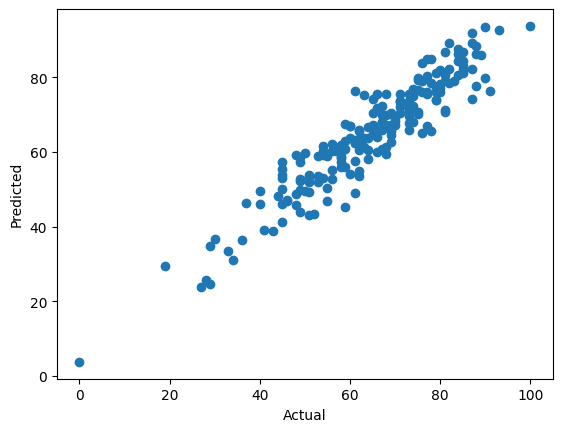

In [13]:
plt.scatter(Y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

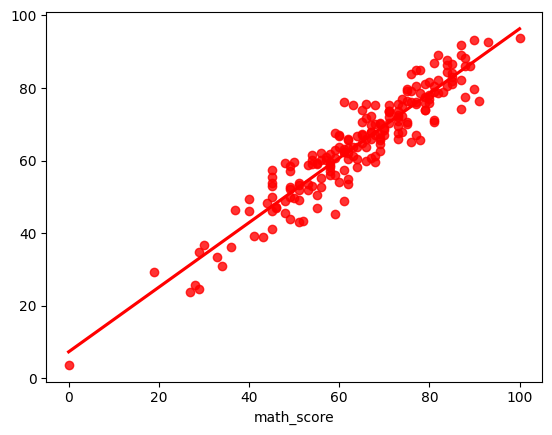

In [14]:
sns.regplot(x=Y_test, y=y_test_pred, ci=None, color="red")

In [15]:
pred_df = pd.DataFrame({"Actual":Y_test, "Predicted":y_test_pred, "Diffrence":Y_test-y_test_pred})
pred_df.to_csv("actual_vs_predicted.csv", index=False)
pred_df

,Actual,Predicted,Diffrence
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287


In [16]:
import joblib
joblib.dump(model, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [17]:
new_student = pd.DataFrame({
    "gender": ["female"],
    "race_ethnicity": ["group C"],
    "parental_level_of_education": ["associate's degree"],
    "lunch": ["standard"],
    "test_preparation_course": ["none"],
    "reading_score": [66],
    "writing_score": [67],
    "math_score": [59]
})

In [18]:
X_new = new_student.drop(columns=["math_score"])
X_new_processed = preprocessor.transform(X_new)

In [19]:
predicted_math_score = model.predict(X_new_processed)[0]
predicted_math_score

59.357003581482196

In [20]:
actual_math_score = new_student["math_score"].values[0]
difference = actual_math_score - predicted_math_score

comparison = pd.DataFrame({
    "Actual Math Score": [actual_math_score],
    "Predicted Math Score": [predicted_math_score],
    "Difference": [difference]
})

comparison

,Actual Math Score,Predicted Math Score,Difference
0,59,59.357004,-0.357004
